In [2]:
!pip -q install pandas numpy matplotlib seaborn openpyxl

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [4]:
rows = [
    ["Schaefer", "Pearson", 0.82],
    ["Schaefer", "PartialCorr", 0.76],
    ["AAL", "Pearson", 0.71],
    ["AAL", "PartialCorr", 0.66],
    ["Power", "Pearson", 0.79],
    ["Power", "PartialCorr", 0.73]
]

df = pd.DataFrame(
    rows,
    columns=["atlas", "metric", "repro_score"]
)

df

,atlas,metric,repro_score
0,Schaefer,Pearson,0.82
1,Schaefer,PartialCorr,0.76
2,AAL,Pearson,0.71
3,AAL,PartialCorr,0.66
4,Power,Pearson,0.79
5,Power,PartialCorr,0.73


In [5]:
pivot = df.pivot(
    index="atlas",
    columns="metric",
    values="repro_score"
)

pivot

metric,PartialCorr,Pearson
atlas,,
AAL,0.66,0.71
Power,0.73,0.79
Schaefer,0.76,0.82


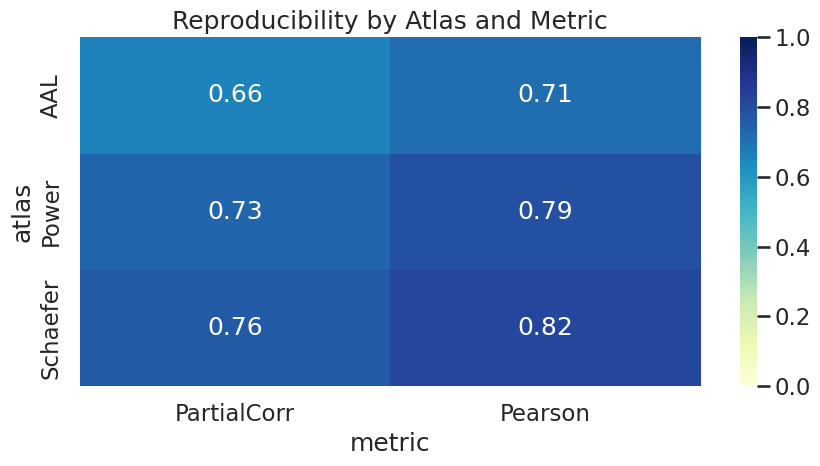

In [6]:
plt.figure(figsize=(9,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)

plt.title("Reproducibility by Atlas and Metric")
plt.tight_layout()
plt.savefig("figures/03_atlas_metric_heatmap.png", dpi=300)
plt.show()

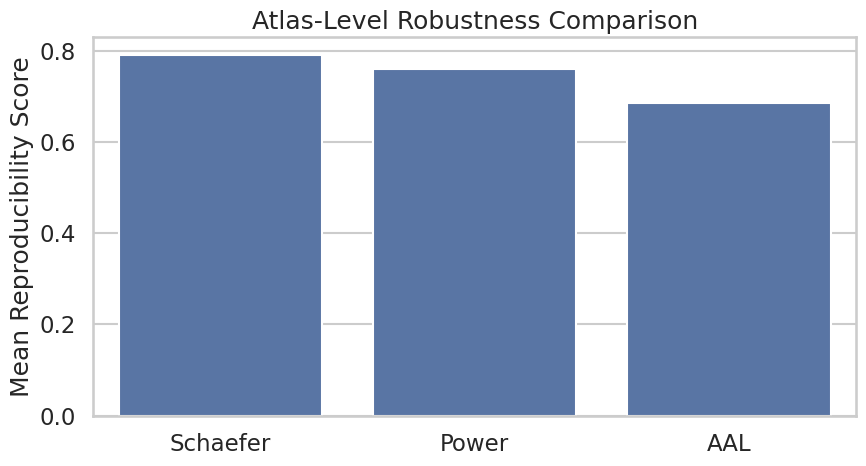

In [7]:
summary = (
    df.groupby("atlas")["repro_score"]
    .mean()
    .reset_index()
    .sort_values("repro_score", ascending=False)
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=summary,
    x="atlas",
    y="repro_score"
)

plt.xlabel("")
plt.ylabel("Mean Reproducibility Score")
plt.title("Atlas-Level Robustness Comparison")
plt.tight_layout()
plt.savefig("figures/03_atlas_summary.png", dpi=300)
plt.show()

In [8]:
df.to_csv("outputs/03_atlas_metric_scores.csv", index=False)
summary.to_csv("outputs/03_atlas_summary.csv", index=False)

summary

,atlas,repro_score
2,Schaefer,0.790
1,Power,0.760
0,AAL,0.685
